#### Customer Segmentation Using KMeans Clustering for a Supermarket

*Goal is to segment customers into clusters & identify high-spending customers for targeted marketing strategies.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Data/mall_customers.csv")

In [3]:
import pandas as pd

def quick_eda(df):
    """
    Function performing a quick initial Exploratory Data Analysis on DataFrame df.
    """
    print("Checking first 5 rows")
    print(df.head())
    print('\n')

    print("Checking Shape of DataFrame (Rows, Columns)")
    print(df.shape)
    print('\n')

    print("Checking data types of Columns of DataFrame")
    print(df.dtypes)
    print('\n')

    print("Checking value counts per Column for DataFrame")
    print(df.count())
    print('\n')

    print("Checking unique values per Column for DataFrame")
    print(df.nunique())
    print('\n')

    print("Checking Summary Statistics for numeric columns of DataFrame")
    print(df.describe().round())
    print('\n')

    print("Checking info of DataFrame")
    df.info(show_counts=True)
    print('\n')

    print("Checking for missing values in DataFrame")
    print(df.isna().sum())
    print('\n')

    print("Checking for duplicate values in DataFrame")
    print(df.duplicated().sum())
    print('\n')

    return df

In [4]:
df = quick_eda(df)

Checking first 5 rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Checking Shape of DataFrame (Rows, Columns)
(200, 5)


Checking data types of Columns of DataFrame
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


Checking value counts per Column for DataFrame
CustomerID                200
Gender                    200
Age                       200
Annual Income (k$)        200
Spending Score (1-100)    200
dtype: int64


Checking unique values per Column for DataFrame
CustomerID

In [5]:
import pandas as pd

def quick_data_correlations(df):
    """
    Function performing a quick correlations check on data of DataFrame df & implemeting relavant visualization.
    """
    print("Checking the correlation matrix for numerical columns of DataFrame df to understand correlations")
    correlation_matrix = df.corr(numeric_only=True).round(2)
    print(correlation_matrix)
    print('\n')

    print("Visualizing data of DataFrame df with a heatmap to understand better the correlations")
    heatmap=sns.heatmap(df.corr(numeric_only=True).round(2), annot=True, vmin=-1, vmax=1, cmap='coolwarm');
    heatmap
    plt.show() 
    print('\n')
    
    print("Visualizing data of DataFrame df with a pairplot to understand in depth the correlations")
    sns.pairplot(df);
    plt.show()
    print('\n')

    return df

In [6]:
df = quick_data_correlations(df)

##### Initial Insights

With the visualization of the pairplot and more specific of the two scatterplots 1) Annual Income of Customers & Spending Score & 2)CustomerID & Spending Score: we understand our data for the clustering goal (segmenting customers into clusters & identifying the high-spending customers) have a spherical form. Therefore we also justify that Kmeans Clustering algorithm is the ideal algorithm for this exercise. Also per same scatterplots we expect to see as optimal number of clusters = kappa = 5, when finishing implementing the algorithm.

In [7]:
#Cleaning Columns names (strip whitespace)
df.columns = df.columns.str.strip()
df_columns = list(df.columns)

print("Cleaning Columns of DataFrame & putting them in df_columns list")
print(df_columns)
print('\n')

Cleaning Columns of DataFrame & putting them in df_columns list
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']




##### Checking data values per each Feature

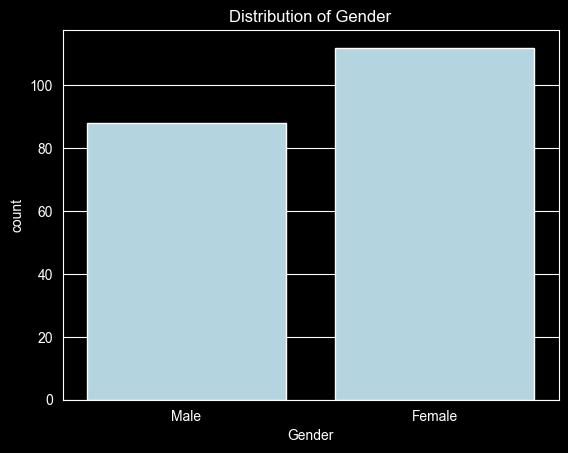

In [8]:
#Checking Column Gender
df['Gender'].value_counts()

#Visualizing data with a Countplot
sns.countplot(data=df,x='Gender',color='lightblue')
plt.title('Distribution of Gender')
plt.show()

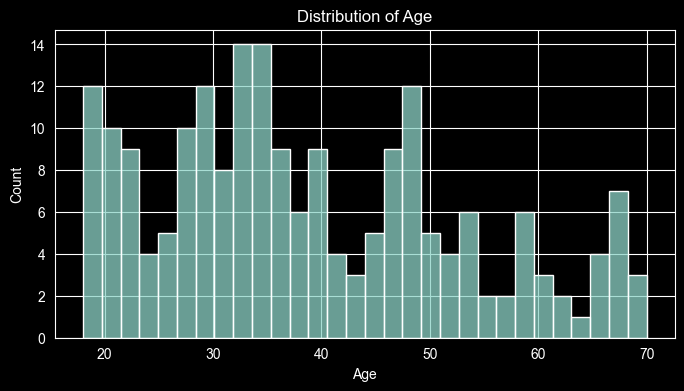

In [9]:
#Checking Column Age

#Checking statistics of Column Age
print(df['Age'].describe().round(2))
print('\n')

print(df['Age'].value_counts())
print('\n')

plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=30) 
plt.title('Distribution of Age')
plt.show()

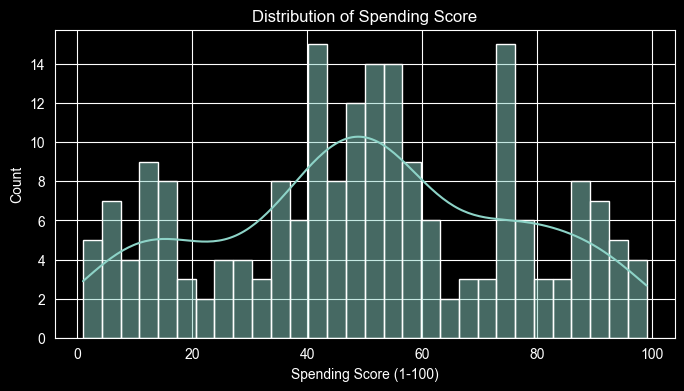

In [10]:
#Checking Column Spending Score (1-100)

#Checking statistics of Column Spending Score (1-100)
print(df['Spending Score (1-100)'].describe().round(2))
print('\n')

print(df['Spending Score (1-100)'].value_counts())
print('\n')

#Checking Skewness
spending_score_skew = df['Spending Score (1-100)'].skew()
print(f"Skewness: {spending_score_skew}")
print('\n')


plt.figure(figsize=(8, 4))
# Using kde=True to add the smooth line
sns.histplot(df['Spending Score (1-100)'], kde=True, bins=30) 
plt.title('Distribution of Spending Score')
plt.show()

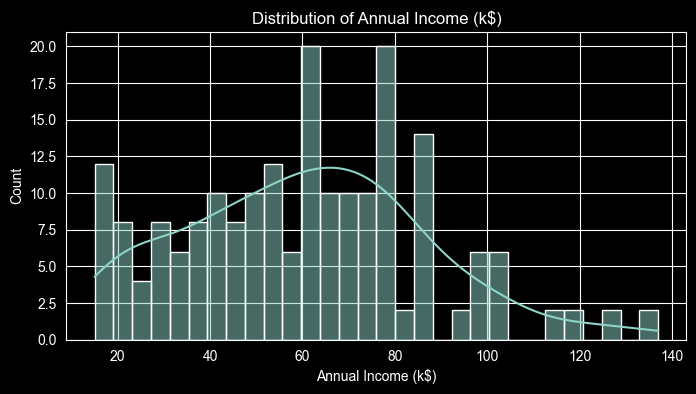

In [11]:
#Checking Column Annual Income (k$)

#Checking statistics of Column base_price
print(df['Annual Income (k$)'].describe().round(2))
print('\n')

print(df['Annual Income (k$)'].value_counts())
print('\n')

#Checking Skewness
annual_income_skew = df['Annual Income (k$)'].skew()
print(f"Skewness: {annual_income_skew}")
print('\n')

#Checking more thoroughly for Outliers of column Annual Income (k$) with a histogram
plt.figure(figsize=(8, 4))
# Using kde=True to add the smooth line
sns.histplot(df['Annual Income (k$)'], kde=True, bins=30) 
plt.title('Distribution of Annual Income (k$)')
plt.show()

In [12]:
#Creating a list for all values of column Annual Income (k$)
Annual_Income = df['Annual Income (k$)'].to_list()

#Splitting base_price values in percentiles 
Q1 = np.percentile(Annual_Income,25,method='midpoint')
Q2 = np.percentile(Annual_Income,50,method='midpoint')
Q3 = np.percentile(Annual_Income,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print('Column Annual Income (k$) Outliers are:')
print(f"Lower Fence : {lower_fence}")
print(f"Upper Fence : {upper_fence}")

Column Annual Income (k$) Outliers are:
Lower Fence : -14.5
Upper Fence : 133.5


In [13]:
#Finding rows with outliers values in column Annual Income (k$)
outliers_Annual_Income_df = df[(df['Annual Income (k$)'] < lower_fence) | (df['Annual Income (k$)'] > upper_fence)]
print("Number of outliers found:", outliers_Annual_Income_df.shape[0])
print('\n')

#Checking outliers of Annual Income (k$) rows
#outliers_Annual_Income_df

Number of outliers found: 2




In [14]:
print('Initial DataFrame shape before removal of  Outliers in column Annual Income (k$):')
print(df.shape)
print('\n')

#Dropping rows with extreme outliers spotted in column Annual Income (k$) by their index
df = df.drop(outliers_Annual_Income_df.index)

print('Updated DataFrame shape after removal of Outliers in column Annual Income (k$):')
print(df.shape)
print('\n')

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column Annual Income (k$)
print(df['Annual Income (k$)'].describe().round(2))

Initial DataFrame shape before removal of  Outliers in column Annual Income (k$):
(200, 5)


Updated DataFrame shape after removal of Outliers in column Annual Income (k$):
(198, 5)


count    198.00
mean      59.79
std       25.24
min       15.00
25%       40.50
50%       61.00
75%       77.75
max      126.00
Name: Annual Income (k$), dtype: float64


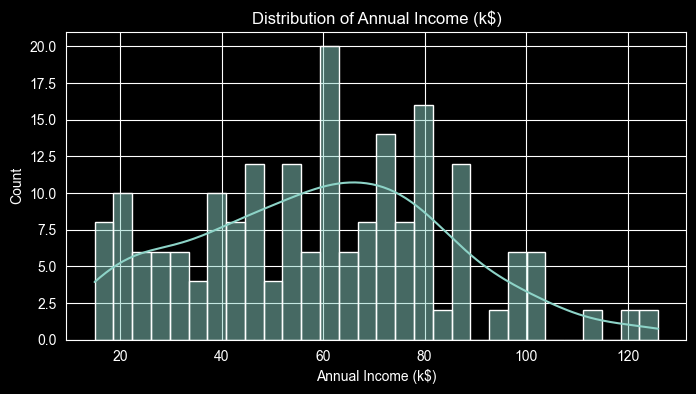

In [15]:
#Checking Skewness
annual_income_skew = df['Annual Income (k$)'].skew()
print(f"Skewness: {annual_income_skew}")
print('\n')

#Checking Annual Income (k$) with a histogram after Outliers handling
plt.figure(figsize=(8, 4))
# Using kde=True to add the smooth line
sns.histplot(df['Annual Income (k$)'], kde=True, bins=30) 
plt.title('Distribution of Annual Income (k$)')
plt.show()

##### Dropping Column CustomerID from DataFrame as it is reduntant

In [16]:
df = df.drop(columns=['CustomerID'])
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


##### Finalizing Features for Modelling

In [17]:
columns_mapping = {"Annual Income (k$)": "Annual_Income","Spending Score (1-100)": "Spending_Score"}

#Applying the renaming of Columns
df = df.rename(columns=columns_mapping)
#df.head()

In [18]:
#Cleaning new Columns names (strip whitespace) & updating Columns list
df.columns = df.columns.str.strip()
df_columns = list(df.columns)

print("Cleaning Columns of DataFrame & putting them in df_columns list")
print(df_columns)
print('\n')

Cleaning Columns of DataFrame & putting them in df_columns list
['Gender', 'Age', 'Annual_Income', 'Spending_Score']




In [19]:
# Applying One-Hot Encoding to convert categorical column Gender to numerical
df = pd.get_dummies(df, columns=['Gender'], prefix='Gender', drop_first=True, dtype=int)

In [20]:
#Cleaning new Column name (strip whitespace if exists) & updating Columns list after One-Hot Encoding
df.columns = df.columns.str.strip()
df_columns = list(df.columns)
final_columns = df_columns

print("Final columns of the DataFrame are:")
print(final_columns)

Final columns of the DataFrame are:
['Age', 'Annual_Income', 'Spending_Score', 'Gender_Male']


##### Finalizing DataFrame for Modeling

In [21]:
#Creating the new final DataFrame for Model
df_final = df[final_columns].copy()

#Checking that all types of Columns are numerical in final DataFrame df_final
print(df_final.dtypes)
print(' ')

# Checking the initial shape of the final DataFrame for Modeling 
print(f"Final DataFrame Initial Shape is: {df_final.shape}")
print(' ')

#Checking in the final DataFrame for Modeling for duplicates
print(f'Final DataFrame duplicate rows are: {df_final.duplicated().sum()}')
print(' ')

#Checking for duplicate rows being fixed
print('Current duplicate rows are:')
print(df_final.duplicated().sum())
print(' ')

#Dropping duplicate data rows found before in final DataFrame df_final
print('Updated duplicate rows are:')
print(df_final.drop_duplicates(inplace=True))
print(' ')
print(f"Final DataFrame after cleaning duplicates Shape is: {df_final.shape}")
print(' ')

#Proactive check in the final DataFrame for Modeling for NaN values
print(f"Remaining NaNs values in final df_final: {df_final.isna().sum()}")
print(' ')

#Reseting index of DataFrame
df_final.reset_index(drop=True,inplace=True)

# Checking the shape of the final DataFrame for Modeling 
print(f"Final DataFrame final Shape: {df_final.shape}")

Age               int64
Annual_Income     int64
Spending_Score    int64
Gender_Male       int64
dtype: object
 
Final DataFrame Initial Shape is: (198, 4)
 
Final DataFrame duplicate rows are: 0
 
Current duplicate rows are:
0
 
Updated duplicate rows are:
None
 
Final DataFrame after cleaning duplicates Shape is: (198, 4)
 
Remaining NaNs values in final df_final: Age               0
Annual_Income     0
Spending_Score    0
Gender_Male       0
dtype: int64
 
Final DataFrame final Shape: (198, 4)


#### Final DataFrame Correlations between features

In [22]:
print("Checking the correlation matrix for numerical columns of DataFrame df to understand correlations:")
correlation_matrix = df_final.corr(numeric_only=True).round(2)
correlation_matrix

,Age,Annual_Income,Spending_Score,Gender_Male
Age,1.00,0.00,-0.33,0.07
Annual_Income,0.00,1.00,0.01,0.02
Spending_Score,-0.33,0.01,1.00,-0.06
Gender_Male,0.07,0.02,-0.06,1.00


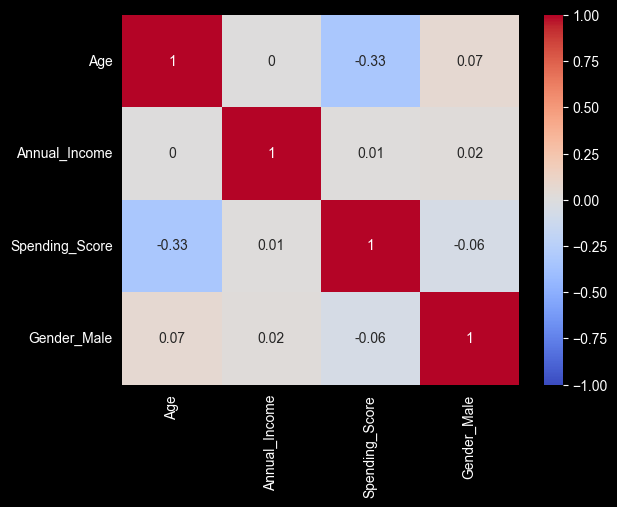

In [23]:
print("Visualizing data of DataFrame df with a heatmap to understand better the correlations:")
heatmap=sns.heatmap(df_final.corr(numeric_only=True).round(2), annot=True, vmin=-1, vmax=1, cmap='coolwarm');
heatmap
plt.show() 

From heatmap we see a positive correlation of Annual_Income to Spending_Score by 0.01. Also, we see a negative correlation of Age to Spending_Score by -0.33 that shows that younger shoppers spend more money. Finally there is a much smaller negative correlation of Gender_Male to Spending_Score by -0.06, meaning Spending_Score isn't in reality affected negatively from whether Gender=Male or Gender=Female.

#### KMeans with using Features Annual Income & Spending Score & Age 
###### Most impactful features were chosen 

##### Scaling Data

In [24]:
features_to_scale = ['Annual_Income', 'Spending_Score','Age'] 
#Standard Scaler
std_scaler = StandardScaler()
standardized = std_scaler.fit_transform(df_final[features_to_scale])
data_scaled = pd.DataFrame(standardized, columns=features_to_scale)
print(data_scaled.head())

#### Applying Kmeans for k=5 per scatterplot indicator found earlier in EDA

In [25]:
kmeans5 = KMeans(
    n_clusters=5,      # number of clusters
    init='k-means++',  # initialization method ('k-means++' is better for convergence)
    n_init=10,         # number of initializations to run
    max_iter=300,      # maximum iterations for a single run
    tol=1e-4,          # convergence threshold
    random_state=42    # seed for reproducibility
)
kmeans5.fit(data_scaled)
# Clustering assignments
labels = kmeans5.labels_
# Clustering centers
centroids = kmeans5.cluster_centers_

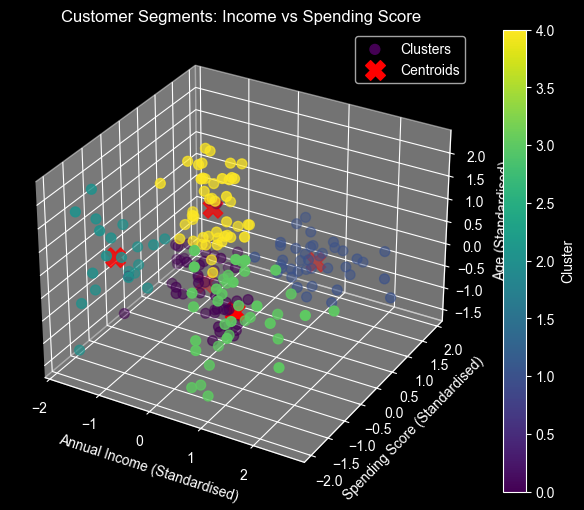

In [26]:
# Visualizing the clusters and centroids

fig = plt.figure(figsize=(8, 6)) 
ax = fig.add_subplot(111, projection='3d')
# Plotting Clusters
sc = ax.scatter(data_scaled.iloc[:, 0], data_scaled.iloc[:, 1], data_scaled.iloc[:, 2], c=labels, cmap='viridis', s=50, label="Clusters")
# Plotting centroids
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], color='red', marker='X', s=200, label="Centroids")
ax.set_title("Customer Segments: Income vs Spending Score")
ax.set_xlabel('Annual Income (Standardised)')
ax.set_ylabel('Spending Score (Standardised)')
ax.set_zlabel('Age (Standardised)')
plt.colorbar(sc, label='Cluster')
plt.legend()
plt.show()

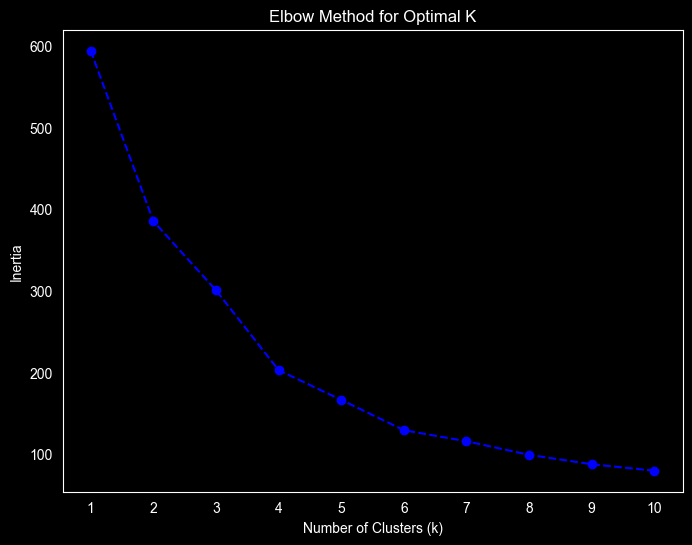

In [27]:
#Applying Elbow Method to check our already found kappa

# Range of cluster numbers to evaluate
k_values = range(1, 11)
inertia_values = []

# Computing KMeans for each k and store inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia_values.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values,
         marker='o',
         linestyle='--',
         color='b')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid()
plt.show()

Possible appearing Elbow points from Elbow Method k=4 or k=6 as after them when adding it we see a relatively small impact on the inertia.

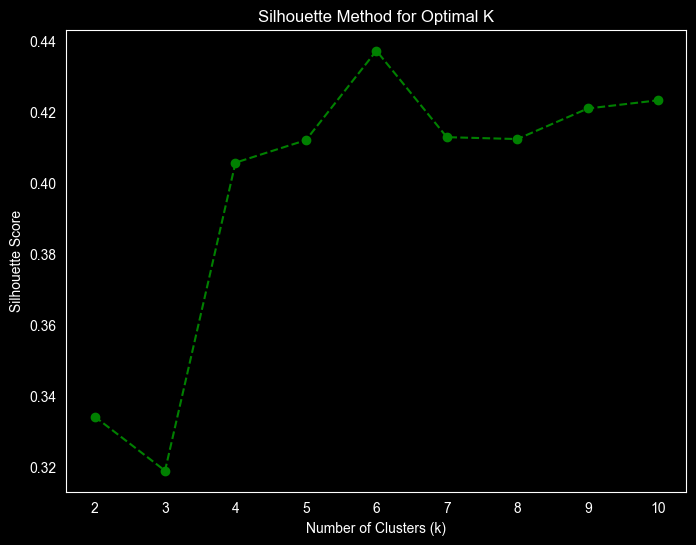

In [28]:
#Applying Silhouette Score Method 

# Range of cluster numbers to evaluate (starting from k=2)
k_values = range(2, 11)
silhouette_scores = []

# Aomputing KMeans for each k and store silhouette score
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)

# Plotting the Silhouette Score Curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, silhouette_scores,
         marker='o',
         linestyle='--',
         color='g')

plt.title("Silhouette Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid()
plt.show()

From Silhoouette Method we see that k=6 is 0,44 and the bigger from k=4.

##### Implementing again Silhouette Score Method for bigger range of clusters to confirm k=6 is the optimal one per our dataset per Silhouette Score

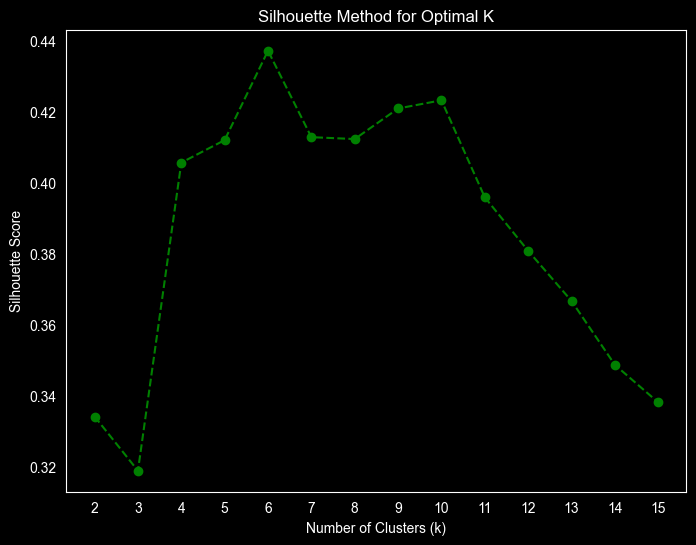

In [29]:
#Applying Silhouette Score Method 

# Range of cluster numbers to evaluate (starting from k=2)
k_values = range(2, 16)
silhouette_scores = []

# Aomputing KMeans for each k and store silhouette score
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)

# Plotting the Silhouette Score Curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, silhouette_scores,
         marker='o',
         linestyle='--',
         color='g')

plt.title("Silhouette Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid()
plt.show()

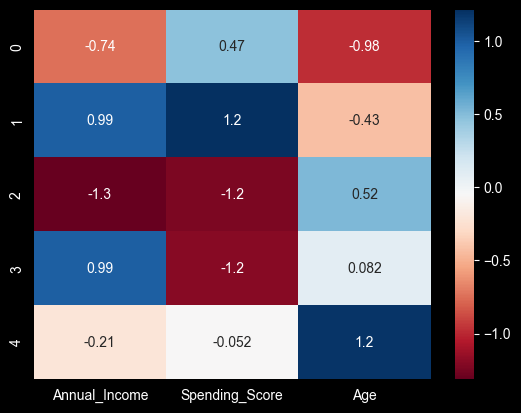

In [30]:
#Viewing the cluster centers
kmeans5.cluster_centers_

#Viewing the cluster centers in a dataframe
cluster_centers = pd.DataFrame(kmeans5.cluster_centers_, columns=data_scaled.columns)
print(cluster_centers)

#Viewing the cluster centers in a heatmap
sns.heatmap(cluster_centers, cmap='RdBu', annot=True);

#### Explanation of Model 1 with KMeans k=5 Clusters 

Considering Age had statistics & data have been standarized (value of 0 represents mean):
min:18, max:70 & mean 39 years

- Cluster 0: High Spending Score, low Income, Teenagers
- Cluster 1: Very High Spending Score,  Very High Income , Adults 
- Cluster 2: Very Low Spending Score, Low Income , Middle-Older-Aged
- Cluster 3: Very Low Spending Score,  Very High Income, Standard-Aged
- Cluster 4: Low Spending Score, Average Income, Senior Older-Aged/Retired

### Examining possible Elbow points found earlier

#### Applying Kmeans for k=4 for Model2

In [31]:
kmeans4 = KMeans(
    n_clusters=4,      # number of clusters
    init='k-means++',  # initialization method ('k-means++' is better for convergence)
    n_init=10,         # number of initializations to run
    max_iter=300,      # maximum iterations for a single run
    tol=1e-4,          # convergence threshold
    random_state=42    # seed for reproducibility
)
kmeans4.fit(data_scaled)
# Clustering assignments
labels = kmeans4.labels_
# Clustering centers
centroids = kmeans4.cluster_centers_

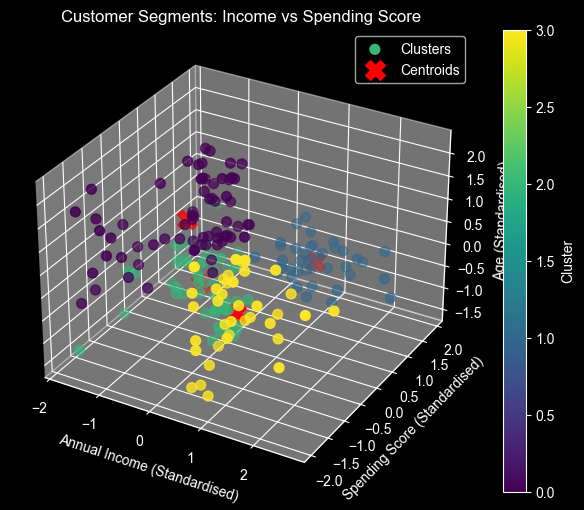

In [32]:
# Visualizing the clusters and centroids
fig = plt.figure(figsize=(8, 6)) 
ax = fig.add_subplot(111, projection='3d')
# Plotting Clusters
sc = ax.scatter(data_scaled.iloc[:, 0], data_scaled.iloc[:, 1], data_scaled.iloc[:, 2], c=labels, cmap='viridis', s=50, label="Clusters")
# Plotting centroids
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], color='red', marker='X', s=200, label="Centroids")
ax.set_title("Customer Segments: Income vs Spending Score")
ax.set_xlabel('Annual Income (Standardised)')
ax.set_ylabel('Spending Score (Standardised)')
ax.set_zlabel('Age (Standardised)')
plt.colorbar(sc, label='Cluster')
plt.legend()
plt.show()

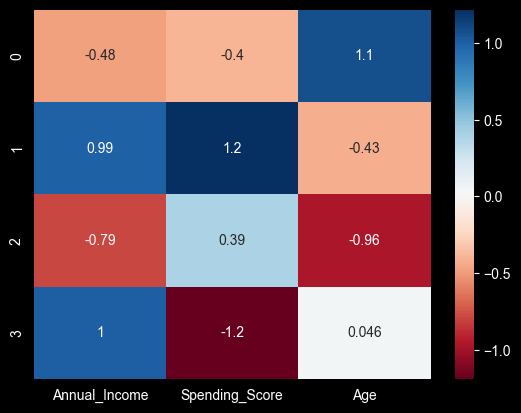

In [33]:
# viewing the cluster centers
kmeans4.cluster_centers_

# viewing the cluster centers in a dataframe
cluster_centers = pd.DataFrame(kmeans4.cluster_centers_, columns=data_scaled.columns)
print(cluster_centers)

# Viewing the cluster centers in a heatmap
sns.heatmap(cluster_centers, cmap='RdBu', annot=True);

Considering Age had statistics & data have been standarized (value of 0 represents mean):
min:18, max:70 & mean 39 years

- Cluster 0: Low Spending Score, Low Income , Senior Older-Aged/Retired
- Cluster 1: Very High Spending Score, High Income , Adults
- Cluster 2: Average Spedning Score, Very Low Income , Teenagers
- Cluster 3: Very Low Spending Score, Very High Income , Middle-Older-Aged

#### Applying Kmeans for k=6 for Model3

In [34]:
kmeans6 = KMeans(
    n_clusters=6,      # number of clusters
    init='k-means++',  # initialization method ('k-means++' is better for convergence)
    n_init=10,         # number of initializations to run
    max_iter=300,      # maximum iterations for a single run
    tol=1e-4,          # convergence threshold
    random_state=42    # seed for reproducibility
)
kmeans6.fit(data_scaled)
# Clustering assignments
labels = kmeans6.labels_
# Clustering centers
centroids = kmeans6.cluster_centers_

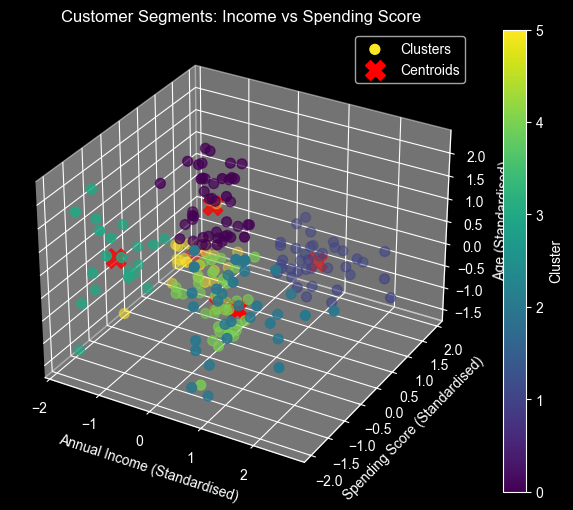

In [35]:
# Visualizing the clusters and centroids
fig = plt.figure(figsize=(8, 6)) 
ax = fig.add_subplot(111, projection='3d')
# Plotting Clusters
sc = ax.scatter(data_scaled.iloc[:, 0], data_scaled.iloc[:, 1], data_scaled.iloc[:, 2], c=labels, cmap='viridis', s=50, label="Clusters")
# Plotting centroids
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], color='red', marker='X', s=200, label="Centroids")
ax.set_title("Customer Segments: Income vs Spending Score")
ax.set_xlabel('Annual Income (Standardised)')
ax.set_ylabel('Spending Score (Standardised)')
ax.set_zlabel('Age (Standardised)')
plt.colorbar(sc, label='Cluster')
plt.legend()
plt.show()

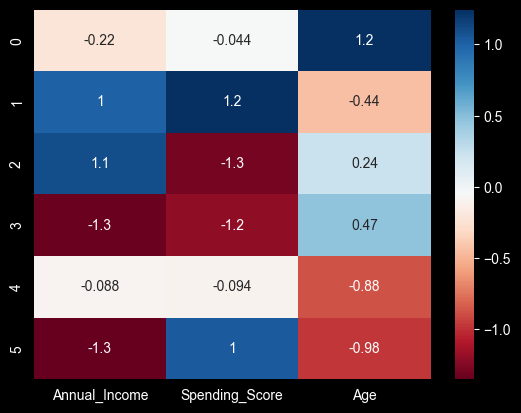

In [36]:
# viewing the cluster centers
kmeans6.cluster_centers_

# viewing the cluster centers in a dataframe
cluster_centers = pd.DataFrame(kmeans6.cluster_centers_, columns=data_scaled.columns)
print(cluster_centers)

# Viewing the cluster centers in a heatmap
sns.heatmap(cluster_centers, cmap='RdBu', annot=True);

Considering Age had statistics & data have been standarized (value of 0 represents mean):
min:18, max:70 & mean 39 years

- Cluster 0: Average Spending Score, Average Income , Older-Aged/Retired
- Cluster 1: Very High Spending Score, Very High Income , Adults
- Cluster 2: Extremely Low Spending Score, Extremely High Income , Standard-Aged
- Cluster 3: Extremely Low Spending Score, Extremely Low Income , Middle-Older-Aged
- Cluster 4: Average Spending Score, Average Income , Working teenagers
- Cluster 5: High Spending Score, Extremely Low Income , Teenagers

#### Selecting the Best KMeans Model

In [37]:
#From Silhouette Score & Elbow Method comparing Model2 (k=4) & Model3 (k=6) but i will check also for Model1 (k=5)
#Model2 for k=5
model1_clusters = pd.Series(kmeans5.labels_, name='model1_clusters')
model1_names = model1_clusters.map({0: 'High Spending Score, low Income, Teenagers',
                                    1: 'Very High Spending Score,  Very High Income , Adults',
                                    2: 'Very Low Spending Score, Low Income , Middle-Older-Aged',
                                    3: 'Very Low Spending Score,  Very High Income, Standard-Aged',
                                    4: 'Low Spending Score, Average Income, Senior Older-Aged/Retired'})
print(model1_names.head())

#Model2 for k=4
model2_clusters = pd.Series(kmeans4.labels_, name='model2_clusters')
model2_names = model2_clusters.map({0: 'Low Spending Score, Low Income , Senior Older-Aged/Retired',
                                    1: 'Very High Spending Score, High Income , Adults',
                                    2: 'Average Spedning Score, Very Low Income , Teenagers',
                                    3: 'Very Low Spending Score, Very High Income , Middle-Older-Aged'})
print(model2_names.head())

#Model3 for k=6
model3_clusters = pd.Series(kmeans6.labels_, name='model3_clusters') 
model3_names = model3_clusters.map({0: 'Average Spending Score, Average Income , Older-Aged/Retired',
                                    1: 'Very High Spending Score, Very High Income , Adults',
                                    2: 'Extremely Low Spending Score, Extremely High Income , Standard-Aged',
                                    3: 'Extremely Low Spending Score, Extremely Low Income , Middle-Older-Aged',
                                    4: 'Average Spending Score, Average Income , Working teenagers',
                                    5: 'High Spending Score, Extremely Low Income , Teenagers'})
print(model3_names.head())

0           High Spending Score, low Income, Teenagers
1           High Spending Score, low Income, Teenagers
2    Very Low Spending Score, Low Income , Middle-O...
3           High Spending Score, low Income, Teenagers
4           High Spending Score, low Income, Teenagers
Name: model1_clusters, dtype: object
0    Average Spedning Score, Very Low Income , Teen...
1    Average Spedning Score, Very Low Income , Teen...
2    Average Spedning Score, Very Low Income , Teen...
3    Average Spedning Score, Very Low Income , Teen...
4    Average Spedning Score, Very Low Income , Teen...
Name: model2_clusters, dtype: object
0    High Spending Score, Extremely Low Income , Te...
1    High Spending Score, Extremely Low Income , Te...
2    Extremely Low Spending Score, Extremely Low In...
3    High Spending Score, Extremely Low Income , Te...
4    Extremely Low Spending Score, Extremely Low In...
Name: model3_clusters, dtype: object


In [38]:
#Checking values per comparing Models
model1_values=model1_names.value_counts()
print(model1_names.value_counts()) #Model 1 captures 2 big clusters 2 medium & 1 more specific.
print(' ')
model2_values=model2_names.value_counts()
print(model2_names.value_counts()) #Model 2 captures 2 big clusters and 2 other a bit more specific.
print(' ')
model3_values=model3_names.value_counts()
print(model3_names.value_counts()) #Model 3 captures 1 big cluster and 5 more specific ones. 

model1_clusters
High Spending Score, low Income, Teenagers                       54
Low Spending Score, Average Income, Senior Older-Aged/Retired    47
Very High Spending Score,  Very High Income , Adults             39
Very Low Spending Score,  Very High Income, Standard-Aged        38
Very Low Spending Score, Low Income , Middle-Older-Aged          20
Name: count, dtype: int64
 
model2_clusters
Low Spending Score, Low Income , Senior Older-Aged/Retired       65
Average Spedning Score, Very Low Income , Teenagers              57
Very High Spending Score, High Income , Adults                   39
Very Low Spending Score, Very High Income , Middle-Older-Aged    37
Name: count, dtype: int64
 
model3_clusters
Average Spending Score, Average Income , Older-Aged/Retired               45
Average Spending Score, Average Income , Working teenagers                38
Very High Spending Score, Very High Income , Adults                       38
Extremely Low Spending Score, Extremely High Income ,

In [39]:
df_final.head()

,Age,Annual_Income,Spending_Score,Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


In [40]:
#Consolidating DataFrame with label of each Model
cluster_names = pd.concat([df_final, model1_names,model2_names, model3_names], axis=1)
#cluster_names

#Checking main statistics of our DataFrame Grouped by Model with k=4 and after with Model with k=5 and k=6
summary_both = (cluster_names.groupby(['model2_clusters','model1_clusters', 'model3_clusters'])
    [['Spending_Score', 'Annual_Income', 'Age']]
    .mean())
summary_both = summary_both.round(1)
summary_both

Spending_Score  \
model2_clusters                                    model1_clusters                                    model3_clusters                                                      
Average Spedning Score, Very Low Income , Teena... High Spending Score, low Income, Teenagers         Average Spending Score, Average Income , Workin...            50.9   
                                                                                                      Extremely Low Spending Score, Extremely Low Inc...            40.0   
                                                                                                      High Spending Score, Extremely Low Income , Tee...            76.9   
                                                   Very Low Spending Score, Low Income , Middle-Ol... Extremely Low Spending Score, Extremely Low Inc...            25.3   
Low Spending Score, Low Income , Senior Older-A... Low Spending Score, Average Income, Senior Olde... Average Spending Score, Average Income , Older-...            49.1   
                                                                                                      Average Spending Score, Average Income , Workin...            44.0   
                                                   Very Low Spending Score,  Very High Income, Sta... Extremely Low Spending Score, Extremely High In...            11.0   
                                                   Very Low Spending Score, Low Income , Middle-Ol... Extremely Low Spending Score, Extremely Low Inc...            17.1   
Very High Spending Score, High Income , Adults     Very High Spending Score,  Very High Income , A... Average Spending Score, Average Income , Workin...            58.0   
                                                                                                      Very High Spending Score, Very High Income , Ad...            82.1   
Very Low Spending Score, Very High Income , Mid... Very Low Spending Score,  Very High Income, Sta... Average Spending Score, Average Income , Workin...            32.5   
                                                                                                      Extremely Low Spending Score, Extremely High In...            17.1   

                                                                                                                                                          Annual_Income  \
model2_clusters                                    model1_clusters                                    model3_clusters                                                     
Average Spedning Score, Very Low Income , Teena... High Spending Score, low Income, Teenagers         Average Spending Score, Average Income , Workin...           54.6   
                                                                                                      Extremely Low Spending Score, Extremely Low Inc...           17.0   
                                                                                                      High Spending Score, Extremely Low Income , Tee...           25.8   
                                                   Very Low Spending Score, Low Income , Middle-Ol... Extremely Low Spending Score, Extremely Low Inc...           20.3   
Low Spending Score, Low Income , Senior Older-A... Low Spending Score, Average Income, Senior Olde... Average Spending Score, Average Income , Older-...           54.3   
                                                                                                      Average Spending Score, Average Income , Workin...           57.0   
                                                   Very Low Spending Score,  Very High Income, Sta... Extremely Low Spending Score, Extremely High In...           71.0   
                                                   Very Low Spending Score, Low Income , Middle-Ol... Extremely Low Spending Score, Extremely Low Inc...           27.9   
Very High Spending Score, High Inco

In [41]:
#Checking main statistics of our DataFrame Grouped by Model2 with k=4
summary2 = (cluster_names.groupby('model2_clusters')
            .agg({'Spending_Score': 'mean','Annual_Income': 'mean','Age': 'mean','model2_clusters': 'count'})
            .rename(columns={'model2_clusters': 'Count'})
            .round(1))
summary2

,Spending_Score,Annual_Income,Age,Count
model2_clusters,,,,
"Average Spedning Score, Very Low Income , Teenagers",60.3,40.0,25.4,57
"Low Spending Score, Low Income , Senior Older-Aged/Retired",40.0,47.7,54.0,65
"Very High Spending Score, High Income , Adults",81.5,84.8,32.9,39
"Very Low Spending Score, Very High Income , Middle-Older-Aged",19.6,85.1,39.6,37


##### Clusters Segmentation for Model 2 with k=4 per highest Spending Score 

1. Cluster Segmentation per Spending (Very High Spending, High Income, Adults)
- Customers profile: Average Age ~33, High Income (~85k), High Spending (81,5), Customers number (39)

2. Cluster Segmentation per Spending (Average Spending, Very Low Income, Teenagers)
- Customers profile: Average Age ~26, Low Income (~40k) but High Spending (~60), Customers number (57)

3. Cluster Segmentation per Spending (Low Spending Score, Low Income , Senior Older-Aged/Retired) 
- Customers profile: Average Age ~54, Average Income (~48k), Average Spending (~40), Customers number (65)

4. Cluster Segmentation per Spending (Very Low Spending Score, Very High Income , Middle-Older-Aged)
- Customers profile: Average Age ~40, Average Income (~85k), Average Spending (~20), Customers number (37)

In [42]:
#Checking main statistics of our DataFrame Grouped by Model1 with k=5
summary1 = (cluster_names.groupby('model1_clusters')
            .agg({'Spending_Score': 'mean','Annual_Income': 'mean','Age': 'mean','model2_clusters': 'count'})
            .rename(columns={'model2_clusters': 'Count'})
            .round(1))
summary1

,Spending_Score,Annual_Income,Age,Count
model1_clusters,,,,
"High Spending Score, low Income, Teenagers",62.2,41.1,25.2,54
"Low Spending Score, Average Income, Senior Older-Aged/Retired",48.9,54.4,55.6,47
"Very High Spending Score, Very High Income , Adults",81.5,84.8,32.9,39
"Very Low Spending Score, Very High Income, Standard-Aged",19.4,84.8,40.1,38
"Very Low Spending Score, Low Income , Middle-Older-Aged",18.4,26.8,46.2,20


##### Clusters Segmentation for Model 1 with k=5 per highest Spending Score 

1. Cluster Segmentation per Spending (Very High Spending Score, Very High Income , Adults)
- Customers profile: Average Age ~33, Very High Income (~85k), Very High Spending (81.5), Customers number (39)

2. Cluster Segmentation per Spending (High Spending Score, low Income, Teenagers)
- Customers profile: Average Age ~25, Low Income (~41k), High Spending (~62), Customers number (54)

3. Cluster Segmentation per Spending (Low Spending Score, Average Income, Senior Older-Aged/Retired)
- Customers profile: Average Age ~56, Average Income (~54,5k), Low Spending (~49), Customers number (47)

4. Cluster Segmentation per Spending (Very Low Spending Score, Very High Income, Standard-Aged)
- Customers profile: Average Age ~40, Very High Income Income (~85k), Very Low  Spending (~19,5), Customers number (38)

5. Cluster Segmentation per Spending (Very Low Spending Score, Low Income , Middle-Older-Aged)
- Customers profile: Average Age ~46, Low Income (~27k), Very Low Spending (~18,5), Customers number (20)

In [43]:
#Checking main statistics of our DataFrame Grouped by Model3 with k=6
summary3 = (cluster_names.groupby('model3_clusters')
            .agg({'Spending_Score': 'mean','Annual_Income': 'mean','Age': 'mean','model3_clusters': 'count'})
            .rename(columns={'model3_clusters': 'Count'})
            .round(1))
summary3

,Spending_Score,Annual_Income,Age,Count
model3_clusters,,,,
"Average Spending Score, Average Income , Older-Aged/Retired",49.1,54.3,56.3,45
"Average Spending Score, Average Income , Working teenagers",47.8,57.6,26.7,38
"Extremely Low Spending Score, Extremely High Income , Standard-Aged",16.9,87.4,42.2,32
"Extremely Low Spending Score, Extremely Low Income , Middle-Older-Aged",19.4,26.3,45.5,21
"High Spending Score, Extremely Low Income , Teenagers",76.9,25.8,25.2,24
"Very High Spending Score, Very High Income , Adults",82.1,85.2,32.8,38


##### Clusters Segmentation for Model 3 with k=6 per highest Spending Score 

1. Cluster Segmentation per Spending (Very High Spending Score, Very High Income , Adults)
- Customers profile: Average Age ~33, Very High Income (~85k), Very High Spending (~82), Customers number (38)

2. Cluster Segmentation per Spending (High Spending Score, Extremely Low Income , Teenagers)
- Customers profile: Average Age ~25, Extremely Low Income (~26k), High Spending (~77), Customers number (24)

3. Cluster Segmentation per Spending (Average Spending Score, Average Income , Older-Aged/Retired)
- Customers profile: Average Age ~56, Average Income (~54k), Average Spending (~49), Customers number (45)

4. Cluster Segmentation per Spending (Average Spending Score, Average Income , Working teenagers)
- Customers profile: Average Age ~27, Average Income (~58k), Average Spending (~48), Customers number (38)

5. Cluster Segmentation per Spending (Extremely Low Spending Score, Extremely Low Income , Middle-Older-Aged)
- Customers profile: Average Age ~46, High Income (26~k), High Spending (19,5~), Customers number (21)

6. Cluster Segmentation per Spending (Extremely Low Spending Score, Extremely High Income , Standard-Aged)
- Customers profile: Average Age ~42, High Income (87,5~k), High Spending (17~), Customers number (32)

#### Conclusions after seeing in depth each model & comparing them:
1. According to Silhouette Score as mentioned earlier k=4 appears to be the optimal choice. Per Elbow method k=4 or k=6 are the potential Elbow points.
   
2. Model3 with k=6 includes 2 Segments similar between them regarding Spending Score (16.9 & 19.4) with main difference between them the Annual Income (High in the 1st one with value 87.4 and Low in the 2nd one with 26.3). And Segmentation is for a Supermarket where prices are not as expensive as it would be for example for a Luxury Tourist Hotel Resort. Therefore rejecting due to this to use k=6 as optimal.

3. Model1 with k=5 includes 2 Segments similar between them regarding Spending Score (19.4 & 18.4) with main difference between them the Annual Income (High in the 1st one with value 84.8 and Low in the 2nd one with 26.8). And Segmentation is for a Supermarket where prices are not as expensive as it would be for example for a Luxury Tourist Hotel Resort. Therefore rejecting due to this to use k=5 as optimal.

4. Choosing as optimal k, k=4 with Model2, due to above and the fact that it's more feasible to create a smaller number of campaigns to target also many Customers of possible new Spending. Ideally advice for Marketing would be to target first the cluster with the High Spending (Very High Spending, High Income, Adults). After to target the cluster with the Average Spending Customers (Average Spending, Very Low Income, Teenagers) and last the Low Spending with lots of main characteristics group created (Low Spending, Very Low Income, Senior Older-Aged/Retired)

#### Clusters Segmentation for Selected Model (k=4) per highest Spending Score for Marketing

1. Cluster Segmentation per Spending (Very High Spending, High Income, Adults)
- Customers profile: Average Age ~33, High Income (~85k), High Spending (81,5), Customers number (39)

2. Cluster Segmentation per Spending (Average Spending, Very Low Income, Teenagers)
- Customers profile: Average Age ~26, Low Income (~40k) but High Spending (~60), Customers number (57)

3. Cluster Segmentation per Spending (Low Spending Score, Low Income , Senior Older-Aged/Retired) 
- Customers profile: Average Age ~54, Average Income (~48k), Average Spending (~40), Customers number (65)

4. Cluster Segmentation per Spending (Very Low Spending Score, Very High Income , Middle-Older-Aged)
- Customers profile: Average Age ~40, Average Income (~85k), Average Spending (~20), Customers number (37)